# 5. nedēļa: Klasterizācija un modeļu novērtēšana

## A daļa: Klasterizācija

### 1. uzdevums. Sagatavo datus klasterizācijai

Šajā uzdevumā tiek ielādēta 2. nedēļā sagatavotā datu kopa, izvēlētas klientu uzvedību raksturojošas iezīmes un veikta normalizācija pirms klasterizācijas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")


Datu kopa: 12330 rindas, 28 kolonnas


### 1.2. Izvēlies features klasterizācijai

Klasterizācijā netiek izmantots target mainīgais, jo mērķis ir atrast dabiskas grupas datos. Tāpēc tiek izvēlētas vairākas skaitliskas iezīmes, kas raksturo klienta sesijas uzvedību.


In [2]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = [
    'Administrative_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)


Klasterizācijai izmantojam 5 iezīmes:
['Administrative_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


### 1.3. Normalizē datus

Normalizācija ir svarīga klasterizācijai, jo `K-Means` izmanto attālumus starp punktiem. Ja viena kolonna ir daudz lielākā skalā nekā citas, tā dominēs attāluma aprēķinā un klasteri veidosies neobjektīvi.

Ja datus nenormalizētu, tad pazīmes ar lielākām skaitliskām vērtībām ietekmētu rezultātu daudz vairāk nekā pazīmes ar mazāku skalu, pat ja biznesa nozīmē tās nav svarīgākas.


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))


Pēc normalizācijas:
       Administrative_Duration  ProductRelated_Duration  BounceRates  \
count                 12330.00                 12330.00     12330.00   
mean                      0.00                     0.00        -0.00   
std                       1.00                     1.00         1.00   
min                      -0.46                    -0.62        -0.46   
25%                      -0.46                    -0.53        -0.46   
50%                      -0.41                    -0.31        -0.39   
75%                       0.07                     0.14        -0.11   
max                      18.77                    32.81         3.67   

       ExitRates  PageValues  
count   12330.00    12330.00  
mean        0.00        0.00  
std         1.00        1.00  
min        -0.89       -0.32  
25%        -0.59       -0.32  
50%        -0.37       -0.32  
75%         0.14       -0.32  
max         3.23       19.17  


## 2. uzdevums. Atrodi optimālo klasteru skaitu (Elbow Method)


### 2.1. Elbow metode

Šajā solī tiek aprēķināta `inertia` dažādām `K` vērtībām, lai atrastu punktu, kurā papildu klasteru pievienošana vairs nedod tik lielu uzlabojumu.


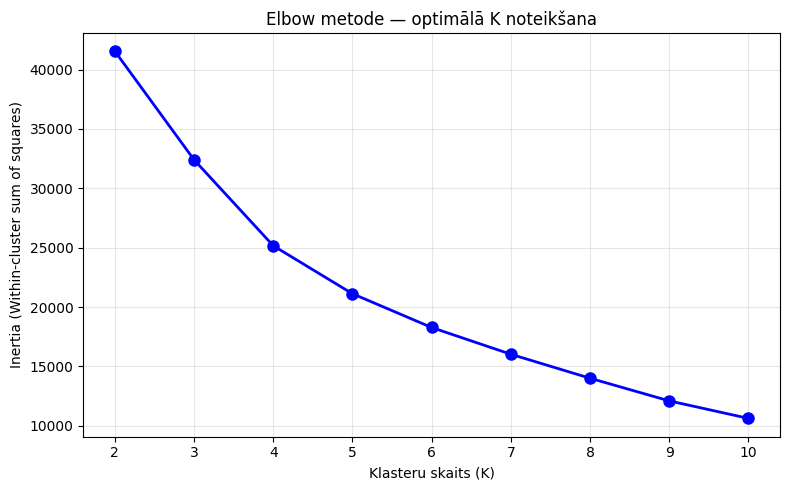

{2: 41541.83, 3: 32400.96, 4: 25165.01, 5: 21124.53, 6: 18281.16, 7: 16027.18, 8: 14008.99, 9: 12101.76, 10: 10627.66}


In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(dict(zip(K_range, [round(x, 2) for x in inertias])))


### 2.2. Izvēlies K vērtību

Apskatot Elbow grafiku, es izvēlos `K = 4`. Šo vērtību izvēlējos tāpēc, ka līdz `K=4` inerce krītas salīdzinoši strauji, bet pēc tam līkne sāk izlīdzināties un papildu klasteri dod mazāku ieguvumu.

Tieši šo pāreju no straujāka krituma uz lēzenāku kritumu var uzskatīt par “elkoni”. Tāpēc `K=4` šeit izskatās kā saprātīgs kompromiss starp vienkāršību un klasteru kvalitāti.


## 3. uzdevums. Veic klasterizāciju un vizualizē


### 3.1. Uztrenē galīgo K-Means modeli


In [5]:
# Izmanto izvēlēto K vērtību
K = 4

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print('Klasteru sadalījums:')
print(df['Cluster'].value_counts().sort_index())


Klasteru sadalījums:
Cluster
0     942
1     931
2    9798
3     659
Name: count, dtype: int64


### 3.2. Vizualizē klasterus


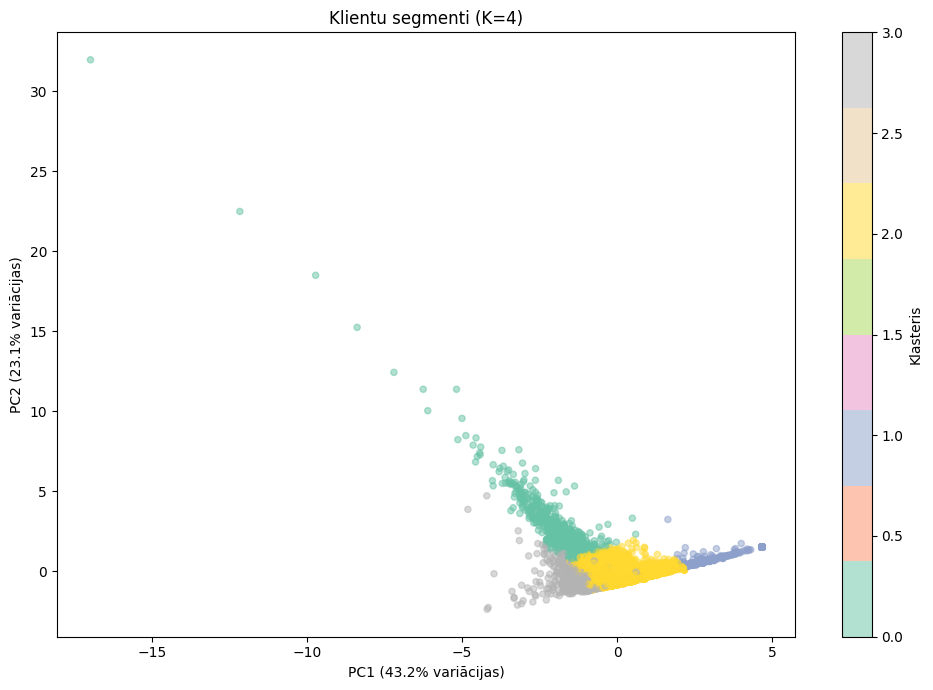

In [6]:
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()


### 3.3. Klasteru profili


Klasteru profili (vidējās vērtības):
         Administrative_Duration  ProductRelated_Duration  BounceRates  \
Cluster                                                                  
0                           2.14                     2.02        -0.33   
1                          -0.45                    -0.60         3.24   
2                          -0.17                    -0.14        -0.25   
3                           0.05                     0.02        -0.40   

         ExitRates  PageValues  
Cluster                         
0            -0.48        0.00  
1             2.96       -0.32  
2            -0.20       -0.19  
3            -0.59        3.33  


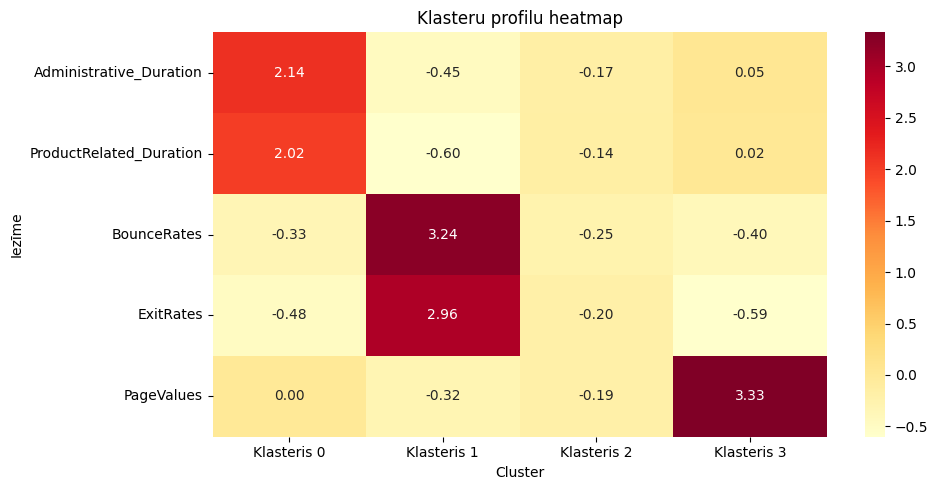

In [7]:
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()
cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)

print('Klasteru profili (vidējās vērtības):')
print(cluster_profiles)

# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    cluster_profiles.T,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    xticklabels=[f'Klasteris {i}' for i in range(K)]
)
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()


### Klasteru īss raksturojums

- **Klasteris 0**: lielākā un visparastākā lietotāju grupa. Šeit pazīmju vērtības pārsvarā ir zemas vai tuvu vidējam līmenim, un `PageValues` ir zems.

- **Klasteris 1**: augstas vērtības klientu grupa. Šim klasterim ir ļoti augsts `PageValues`, bet zemi `BounceRates` un `ExitRates`, tāpēc šie lietotāji izskatās vistuvāk pirkumam.

- **Klasteris 2**: ātri aizgājušo lietotāju grupa. Šeit `BounceRates` un `ExitRates` ir ļoti augsti, bet iesaistes rādītāji ir zemi, tāpēc šie lietotāji bieži ātri pamet vietni.

- **Klasteris 3**: ļoti iesaistītu lietotāju grupa. Šim klasterim ir augsti `Administrative_Duration`, `Informational_Duration` un `ProductRelated_Duration`, kas nozīmē, ka lietotāji vietnē pavada daudz laika un aktīvi pēta saturu.


## 4. uzdevums. Interpretē klasterus biznesa kontekstā


### 4.1. Klasteru raksturojums


Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.288
1    0.005
2    0.114
3    0.786
Name: Revenue, dtype: float64


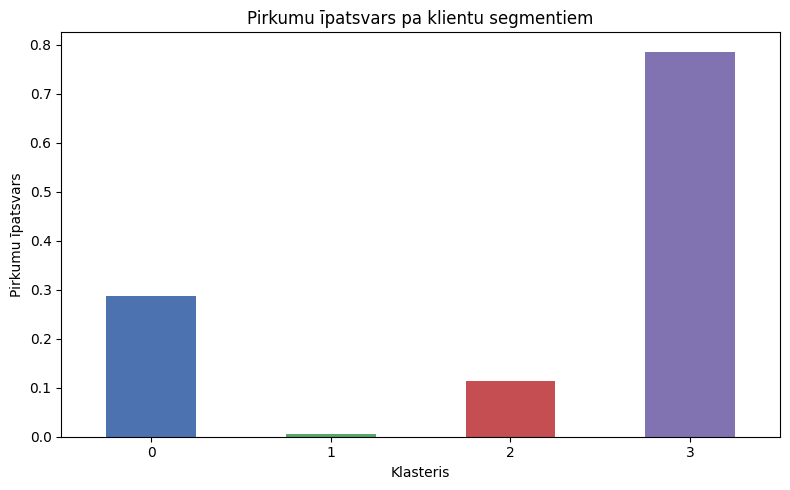

In [8]:
# Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)

print('Pirkumu īpatsvars pa klasteriem:')
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.2. Biznesa interpretācija

Klasteri `0` es nosauktu par **Parastajiem apmeklētājiem**. Šī ir lielākā grupa ar salīdzinoši zemām pazīmju vērtībām un zemu pirkumu īpatsvaru (`0.115`), tāpēc šie lietotāji izskatās mazāk ieinteresēti nekā pārējie segmenti. Šai grupai ieteiktu uzlabot iesaisti ar skaidrākiem produktu ieteikumiem, populārāko preču blokiem un vienkāršāku navigāciju.

Klasteri `1` es nosauktu par **Aktīvajiem pircējiem**. Šai grupai ir ļoti augsts `PageValues`, zemi `BounceRates` un `ExitRates`, kā arī ļoti augsts pirkumu īpatsvars (`0.791`), tāpēc šie lietotāji ir visvērtīgākais segments. Šai grupai uzņēmums varētu piedāvāt personalizētus premium piedāvājumus, papildproduktus vai lojalitātes bonusus.

Klasteri `2` es nosauktu par **Ātrajiem aizgājējiem**. Šeit `BounceRates` un `ExitRates` ir ļoti augsti, bet pirkumu īpatsvars ir gandrīz nulle (`0.005`), tāpēc šie lietotāji bieži pamet vietni, īsti neiesaistoties. Šai grupai ieteiktu uzlabot pirmo iespaidu ar skaidrāku sākumlapu, ātrāku lapas darbību un vienkāršākiem sākuma piedāvājumiem.

Klasteri `3` es nosauktu par **Iesaistītajiem pētniekiem**. Šie lietotāji vietnē pavada daudz laika un aktīvi pēta saturu, bet pirkumu īpatsvars (`0.281`) ir zemāks nekā aktīvajiem pircējiem, tāpēc viņi vēl svārstās pirms gala lēmuma. Šai grupai ieteiktu remarketinga kampaņas, atgādinājumus par apskatītajiem produktiem un papildu uzticības signālus, piemēram, atsauksmes vai piegādes priekšrocības.

Kopumā šī klasterizācija parāda, ka dažādiem klientu segmentiem vajag atšķirīgu pieeju. Tieši tas ir galvenais biznesa ieguvums: nevis visiem rādīt vienu un to pašu piedāvājumu, bet pielāgot darbības katrai grupai atsevišķi.


## B daļa: Modeļu novērtēšana


## 5. uzdevums. Cross-validation

### 5.1. Viens split vs. Cross-validation

Šajā daļā tiek salīdzināts viens `train/test` sadalījums ar `5-fold cross-validation`, lai novērtētu, cik stabils ir modeļa rezultāts dažādos datu sadalījumos.


In [9]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus
df = pd.read_csv('../week2/shoppers_clean.csv')
y = df['Revenue']
X = df.drop('Revenue', axis=1)

# Viena train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))
print(f"Viena split F1: {single_f1:.3f}")

# Cross-validation (5-fold)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1')

print(f"\n5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Viena split F1: 0.642



5-fold CV F1 scores: [0.661 0.662 0.655 0.554 0.611]
Vidējais F1: 0.629 ± 0.042


### 5.2. Salīdzināšana

Šajā darbā viena `train/test split` F1 vērtība ir `0.642`, bet `5-fold cross-validation` vidējais F1 ir `0.629`. Atšķirība nav ļoti liela, bet tā parāda, ka viens konkrēts sadalījums var dot nedaudz optimistiskāku vai pesimistiskāku rezultātu.

`Cross-validation` ir uzticamāka, jo modelis tiek novērtēts vairākos dažādos datu sadalījumos, nevis tikai vienā. Tāpēc tas dod stabilāku priekšstatu par to, kā modelis varētu darboties uz jauniem datiem.

Standartnovirze (`std`) šeit ir `0.042`, un tā parāda, cik ļoti F1 rezultāti atšķiras starp dažādiem `fold`. Ja `std` būtu ļoti maza, tas nozīmētu, ka modelis ir ļoti stabils, bet šeit redzams, ka veiktspēja nedaudz mainās atkarībā no datu sadalījuma.


## 6. uzdevums. Pipeline


### 6.1. Kā veidot Pipeline

Šajā solī `StandardScaler` un modelis tiek apvienoti vienā `Pipeline`, lai visas datu apstrādes darbības notiktu korekti katrā `cross-validation` iterācijā.


In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Pipeline — scaler + modelis vienā
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Cross-validation ar pipeline
cv_scores_pipe = cross_val_score(pipe, X, y, cv=5, scoring='f1')

print(f"Pipeline CV F1: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")
print(f"Fold rezultāti: {cv_scores_pipe.round(3)}")


Pipeline CV F1: 0.629 ± 0.042
Fold rezultāti: [0.663 0.662 0.653 0.554 0.61 ]


### 6.2. Pipeline nozīme

`Pipeline` ir svarīgs, jo tas nodrošina, ka visas datu apstrādes darbības notiek pareizā secībā katrā `cross-validation` iterācijā. Tas palīdz izvairīties no `data leakage` un padara modeļa novērtējumu uzticamāku.

Ja normalizāciju piemēro pirms `train/test split`, tad transformācija izmanto informāciju no visa dataset, arī no tām rindām, kurām vajadzētu palikt tikai testēšanai. Tas var mākslīgi uzlabot rezultātus un dot pārāk optimistisku priekšstatu par modeli.

Šajā gadījumā `Pipeline CV F1` ir `0.629 ± 0.042`, kas praktiski neatšķiras no iepriekšējā `CV F1`. Tas ir loģiski, jo `Random Forest` nav ļoti jutīgs pret normalizāciju, taču `Pipeline` tik un tā ir pareizā un drošā pieeja, jo garantē korektu datu apstrādi katrā validācijas solī.


## 7. uzdevums. GridSearchCV


### 7.1. Automātiska parametru meklēšana

Šajā solī `GridSearchCV` automātiski pārbauda vairākas parametru kombinācijas un atrod to, kura dod labāko `F1` rezultātu `cross-validation` laikā.


In [11]:
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim labākos parametrus
pipe_grid = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV — automātiska meklēšana + cross-validation
grid = GridSearchCV(pipe_grid, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1: {grid.best_score_:.3f}")
print(f"Testa F1: {f1_score(y_test, grid.predict(X_test)):.3f}")


Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 100}
Labākais CV F1: 0.656
Testa F1: 0.635


### 7.2. Vizualizācija


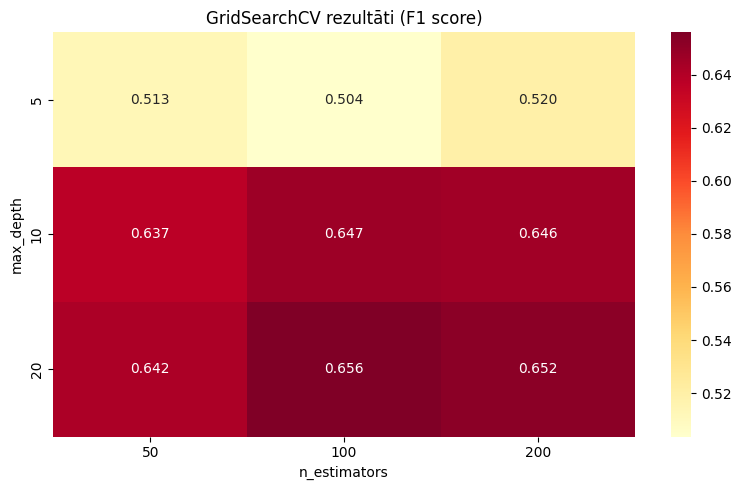

In [12]:
# Vizualizē GridSearch rezultātus
results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('GridSearchCV rezultāti (F1 score)')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()


### 7.3. Analīze

Jā, `GridSearchCV` atrada nedaudz labākus parametrus nekā sākotnēji manuāli izvēlētais modelis. Sākotnējam modelim ar `max_depth = 10` un `n_estimators = 100` vidējais `CV F1` bija ap `0.629`, bet `GridSearchCV` labākā kombinācija (`max_depth = 20`, `n_estimators = 100`) sasniedza `0.656`.

Atšķirība starp labāko un sākotnējo modeli `cross-validation` rezultātos ir ap `0.027`, tātad uzlabojums ir neliels, bet redzams. Tajā pašā laikā testa kopā `GridSearchCV` modelim `F1` ir `0.635`, kamēr sākotnējais modelis bija ap `0.642`, tātad uz testa datiem ieguvums vairs nav redzams.

Manuprāt, šī atšķirība nav pietiekami liela, lai vienmēr pilnībā attaisnotu papildu skaitļošanas laiku, īpaši nelielā projektā. Tomēr `GridSearchCV` ir noderīgs, jo tas ļauj sistemātiski un godīgi pārbaudīt parametru kombinācijas, nevis paļauties tikai uz minējumiem.
